In [14]:
from models.GeoTKG import GeoTKG
import torch
from torch.optim import AdamW
from transformers import get_cosine_schedule_with_warmup
from models.TIEUtils import collator as tie_collator, TemporalDataset
from models.GeoUtils import collator as geo_collator, GeoDataset
from models.TimexNormUtils import collator as norm_collator
from torch.utils.data import DataLoader
from torch.utils.data import Sampler

class EpochRandomSubsetSampler(Sampler):
    def __init__(self, data_source, subset_size):
        self.data_source = data_source
        self.subset_size = subset_size

    def __iter__(self):
        # Pick a new random subset each epoch
        indices = torch.randperm(len(self.data_source))[:self.subset_size]
        return iter(indices.tolist())

    def __len__(self):
        return self.subset_size


In [2]:
NUM_EPOCHS = 20
ENC_LR = 5e-5
NONENC_LR = 1e-3
WARMUP_EPOCHS = 5
LOGGING_EPOCHS = 5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 4
EEPOCH_SIZE = 5400

In [15]:
cleandata_path = "D:\\GeoTKG\\cleandata\\tie\\"
tie_train = TemporalDataset(cleandata_path + "combined.json")
tie_test = TemporalDataset(cleandata_path + "test.json")
tie_sampler = EpochRandomSubsetSampler(tie_train, EEPOCH_SIZE)
tie_train_loader = DataLoader(tie_train, batch_size=BATCH_SIZE, collate_fn=tie_collator, sampler=tie_sampler)
tie_test_loader = DataLoader(tie_test, batch_size=BATCH_SIZE, shuffle=False, collate_fn=tie_collator)

cleandata_path = "D:\\GeoTKG\\cleandata\\geo\\"
geo_train = GeoDataset(cleandata_path + "train.json")
geo_eval = GeoDataset(cleandata_path + "eval.json")
geo_sampler = EpochRandomSubsetSampler(geo_train, EEPOCH_SIZE)
geo_train_loader = DataLoader(geo_train, batch_size=BATCH_SIZE, collate_fn=geo_collator, sampler=geo_sampler)
geo_eval_loader = DataLoader(geo_eval, batch_size=BATCH_SIZE, shuffle=False, collate_fn=geo_collator)

cleandata_path = "D:\\GeoTKG\\cleandata\\normalise\\"
norm_train = TemporalDataset(cleandata_path + "combined.json")
norm_test = TemporalDataset(cleandata_path + "test.json")
norm_sampler = EpochRandomSubsetSampler(norm_train, EEPOCH_SIZE)
norm_train_loader = DataLoader(norm_train, batch_size=BATCH_SIZE, collate_fn=norm_collator, sampler=norm_sampler)
norm_test_loader = DataLoader(norm_test, batch_size=BATCH_SIZE, shuffle=False, collate_fn=norm_collator)

In [4]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = GeoTKG(use_ca=False).to(device)

optimizer = AdamW([
        {"params": [p for n,p in model.named_parameters() if n.startswith("tie_model.enc.") or n.startswith("geo_model.enc.") or n.startswith("norm_model.")], "lr": ENC_LR},
        {"params": [p for n,p in model.named_parameters() if not n.startswith("tie_model.enc.") and not n.startswith("geo_model.enc.") and not n.startswith("norm_model.")], "lr": NONENC_LR},
    ], weight_decay=0.01)

steps_per_epoch = min(len(tie_train_loader), len(geo_train_loader), len(norm_train_loader))
num_train_steps = steps_per_epoch * NUM_EPOCHS
num_warmup_steps = int(0.05 * num_train_steps)
sched = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_train_steps)


scaler = torch.amp.GradScaler(enabled=(device.type=='cuda'))

Some weights of the model checkpoint at roberta-base were not used when initializing RobertaModel: ['lm_head.dense.bias', 'lm_head.bias', 'lm_head.layer_norm.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.weight']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
d:\GeoTKG\venv\Lib\site-packages

In [5]:
global_step = 0
history = {#  Training
           "loss": [], "tie_loss":[], "norm_loss":[], "geo_loss":[],
           #  Evaluation
           "et_ner_f1": [], 'geo_ner_f1':[], "et_f1": [], "ee_f1": [], "norm_strict":[], "norm_relaxed":[], 
           "eval_loss":[], "eval_tie_loss":[], "eval_norm_loss":[], "eval_geo_loss":[]}

for epoch in range(NUM_EPOCHS):
    model.train()
    optimizer.zero_grad(set_to_none=True)
    loss_sum = 0
    tie_loss_sum = 0
    norm_loss_sum = 0
    geo_loss_sum = 0
    for step, (tie_batch, geo_batch, norm_batch) in enumerate(zip(tie_train_loader, geo_train_loader, norm_train_loader)):
        tie_batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in tie_batch.items()}
        geo_batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in geo_batch.items()}
        norm_batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in norm_batch.items()}
        out = model(tie_batch, geo_batch, norm_batch)
        loss =  out["tie_loss"] + 2*out["geo_loss"] + out["norm_loss"]
        loss_sum += loss.item()
        tie_loss_sum += out["tie_loss"].item()
        norm_loss_sum += out["norm_loss"].item()
        geo_loss_sum += out["geo_loss"].item()

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        prev_scale = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        sched.step() if scaler.get_scale() <= prev_scale else None
        optimizer.zero_grad(set_to_none=True)

        if step % 400 == 0:
            print(f"ep {epoch+((step+1)/steps_per_epoch):.2f} train_loss={(loss_sum/(step+1)):.4f} lr={sched.get_last_lr()[0]:.6e}")

        global_step += 1

    print(f"Epoch {epoch+1} done. Avg Loss: {loss_sum / steps_per_epoch:.4f}")

    # ---- validation ----
    if (epoch + 1) % LOGGING_EPOCHS == 0:
        model.eval()
        with torch.no_grad():
            batch_evaluation = model.evaluate_dataloaders(tie_test_loader, geo_eval_loader, norm_test_loader)
            history["et_ner_f1"].append(batch_evaluation["et_ner_f1"])
            history["geo_ner_f1"].append(batch_evaluation["geo_ner_f1"])
            history["norm_strict"].append(batch_evaluation["norm_strict"])
            history["norm_relaxed"].append(batch_evaluation["norm_relaxed"])
            history["et_f1"].append(batch_evaluation["et_f1"])
            history["ee_f1"].append(batch_evaluation["ee_f1"])
            history["eval_loss"].append(batch_evaluation["eval_loss"])
            history["eval_tie_loss"].append(batch_evaluation["eval_tie_loss"])
            history["eval_geo_loss"].append(batch_evaluation["eval_geo_loss"])
            history["eval_norm_loss"].append(batch_evaluation["eval_norm_loss"])
            history["loss"].append(loss_sum / steps_per_epoch)
            history["tie_loss"].append(tie_loss_sum / steps_per_epoch)
            history["geo_loss"].append(geo_loss_sum / steps_per_epoch)
            history["norm_loss"].append(norm_loss_sum / steps_per_epoch)
        model.save(f"D:\\GeoTKG\\results\\geotkg_no_ca\\geotkg_model_epoch{epoch+1}.pt")
        print(f'''EPOCH{epoch+1} \n
            ET NER F1={batch_evaluation['et_ner_f1']:.4f}, GEO NER F1={batch_evaluation['geo_ner_f1']:.4f}, \n
            ET F1={batch_evaluation['et_f1']:.4f}, EE F1={batch_evaluation['ee_f1']:.4f}, \n
            Norm Strict={batch_evaluation['norm_strict']}, Norm Relax={batch_evaluation['norm_relaxed']}\n
            Train Loss={loss_sum / steps_per_epoch:.4f}, Eval Loss={batch_evaluation['eval_loss']:.4f}\n
            Tie Loss ({tie_loss_sum / steps_per_epoch:.4f}, {batch_evaluation["eval_tie_loss"]:.4f}), Geo Loss ({geo_loss_sum / steps_per_epoch:.4f}, {batch_evaluation["eval_geo_loss"]:.4f}), Norm Loss ({norm_loss_sum / steps_per_epoch:.4f}, {norm_loss_sum / steps_per_epoch})''')

ep 0.00 train_loss=16.6270 lr=3.703704e-08
ep 0.30 train_loss=6.6106 lr=1.485185e-05
ep 0.59 train_loss=5.1270 lr=2.966667e-05
ep 0.89 train_loss=4.5698 lr=4.448148e-05
Epoch 1 done. Avg Loss: 4.4421
ep 1.00 train_loss=4.5991 lr=5.000000e-05
ep 1.30 train_loss=3.3511 lr=4.996985e-05
ep 1.59 train_loss=3.3228 lr=4.988009e-05
ep 1.89 train_loss=3.2929 lr=4.973046e-05
Epoch 2 done. Avg Loss: 3.2825
ep 2.00 train_loss=3.6532 lr=4.965903e-05
ep 2.30 train_loss=3.0765 lr=4.942793e-05
ep 2.59 train_loss=3.0842 lr=4.913821e-05
ep 2.89 train_loss=3.0838 lr=4.879057e-05
Epoch 3 done. Avg Loss: 3.0925
ep 3.00 train_loss=2.5615 lr=4.864643e-05
ep 3.30 train_loss=3.0044 lr=4.822066e-05
ep 3.59 train_loss=3.0232 lr=4.773918e-05
ep 3.89 train_loss=3.0006 lr=4.720313e-05
Epoch 4 done. Avg Loss: 3.0046
ep 4.00 train_loss=3.4501 lr=4.698830e-05
ep 4.30 train_loss=3.0007 lr=4.637935e-05
ep 4.59 train_loss=3.0291 lr=4.572080e-05
ep 4.89 train_loss=3.0124 lr=4.501095e-05
Epoch 5 done. Avg Loss: 2.9912
    

d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       AFTER     0.7531    0.8694    0.8071      6547
      BEFORE     0.0000    0.0000    0.0000       510
    CONTAINS     0.2757    0.1761    0.2149       335
      DURING     0.2456    0.0290    0.0519       482
      EQUALS     0.5122    0.5539    0.5322      2042
    IDENTITY     0.2727    0.0252    0.0462       119
    OVERLAPS     0.0000    0.0000    0.0000        13

    accuracy                         0.6866     10048
   macro avg     0.2942    0.2362    0.2361     10048
weighted avg     0.6190    0.6866    0.6442     10048

              precision    recall  f1-score   support

    LOCATION     0.5023    0.6481    0.5660      1006
     MINERAL     0.7793    0.9020    0.8362      1327
 ORE_DEPOSIT     0.8369    0.7102    0.7684       383
        ROCK     0.6560    0.8105    0.7251      1894
       STRAT     0.6126    0.5467    0.5778       642
   TIMESCALE     0.8976    0.8762    0.8867       210

   micro avg     0.6677

d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       AFTER     0.7119    0.9560    0.8161      6547
      BEFORE     0.0000    0.0000    0.0000       510
    CONTAINS     0.2857    0.0299    0.0541       335
      DURING     0.0000    0.0000    0.0000       482
      EQUALS     0.6273    0.3717    0.4668      2042
    IDENTITY     0.6000    0.0504    0.0930       119
    OVERLAPS     0.0000    0.0000    0.0000        13

    accuracy                         0.7000     10048
   macro avg     0.3178    0.2011    0.2043     10048
weighted avg     0.6080    0.7000    0.6295     10048

              precision    recall  f1-score   support

    LOCATION     0.5048    0.6322    0.5613      1006
     MINERAL     0.7717    0.9171    0.8382      1327
 ORE_DEPOSIT     0.7879    0.7467    0.7668       383
        ROCK     0.7277    0.7888    0.7570      1894
       STRAT     0.8061    0.7383    0.7707       642
   TIMESCALE     0.8950    0.9333    0.9138       210

   micro avg     0.7101

d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

    LOCATION     0.5881    0.5974    0.5927      1006
     MINERAL     0.8071    0.9141    0.8572      1327
 ORE_DEPOSIT     0.8720    0.7467    0.8045       383
        ROCK     0.7717    0.7941    0.7827      1894
       STRAT     0.8345    0.7227    0.7746       642
   TIMESCALE     0.9522    0.9476    0.9499       210

   micro avg     0.7665    0.7812    0.7738      5462
   macro avg     0.8042    0.7871    0.7936      5462
weighted avg     0.7678    0.7812    0.7728      5462

EPOCH15 

            ET NER F1=0.9785, GEO NER F1=0.7738, 

            ET F1=0.8694, EE F1=0.7042, 

            Norm Strict=0.7622846202935546, Norm Relax=0.9282067645181876

            Train Loss=2.4938, Eval Loss=2.7408

            Tie Loss (2.3902, 2.0186), Geo Loss (0.0166, 0.5273), Norm Loss (0.0704, 0.07040360918006627)
ep 15.00 train_loss=1.9995 lr=8.088246e-06
ep 15.30 train_loss=2.4967 lr=7.206875e-06
ep 15.59 train_loss=2.4631 lr=6.368203

d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

    LOCATION     0.5809    0.5994    0.5900      1006
     MINERAL     0.8042    0.9194    0.8579      1327
 ORE_DEPOSIT     0.8576    0.7546    0.8028       383
        ROCK     0.7814    0.8041    0.7926      1894
       STRAT     0.8688    0.7321    0.7946       642
   TIMESCALE     0.9476    0.9476    0.9476       210

   micro avg     0.7697    0.7880    0.7787      5462
   macro avg     0.8068    0.7929    0.7976      5462
weighted avg     0.7720    0.7880    0.7781      5462

EPOCH20 

            ET NER F1=0.9780, GEO NER F1=0.7787, 

            ET F1=0.8281, EE F1=0.7101, 

            Norm Strict=0.7708998085513721, Norm Relax=0.9266113592852585

            Train Loss=2.4236, Eval Loss=2.7260

            Tie Loss (2.3549, 1.9952), Geo Loss (0.0105, 0.5292), Norm Loss (0.0478, 0.04779941929764458)


In [6]:
import json
with open("results/geotkg_no_ca/history.json", "w") as f:
    json.dump(history, f, indent=2)

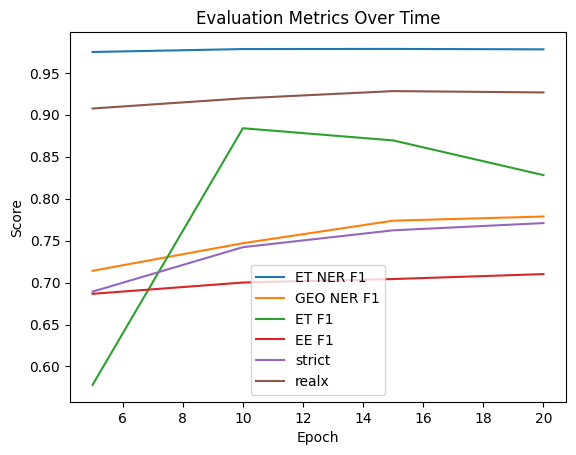

In [7]:
import matplotlib.pyplot as plt

x = list(range(5, 21, 5))

plt.plot(x, history["et_ner_f1"], label="ET NER F1")
plt.plot(x, history["geo_ner_f1"], label="GEO NER F1")
plt.plot(x, history["et_f1"], label="ET F1")
plt.plot(x, history["ee_f1"], label="EE F1")
plt.plot(x, history["norm_strict"], label="strict")
plt.plot(x, history["norm_relaxed"], label="realx")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Evaluation Metrics Over Time")
plt.legend()
plt.show()

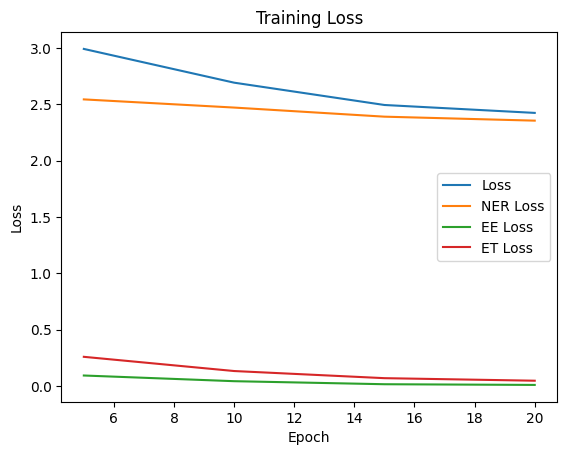

In [8]:
plt.plot(x, history["loss"], label="Loss")
plt.plot(x, history["tie_loss"], label="NER Loss")
plt.plot(x, history["geo_loss"], label="EE Loss")
plt.plot(x, history["norm_loss"], label="ET Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

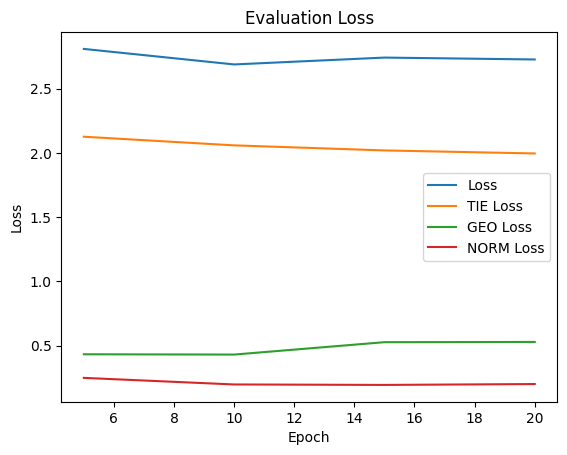

In [9]:
plt.plot(x, history["eval_loss"], label="Loss")
plt.plot(x, history["eval_tie_loss"], label="TIE Loss")
plt.plot(x, history["eval_geo_loss"], label="GEO Loss")
plt.plot(x, history["eval_norm_loss"], label="NORM Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evaluation Loss")
plt.show()

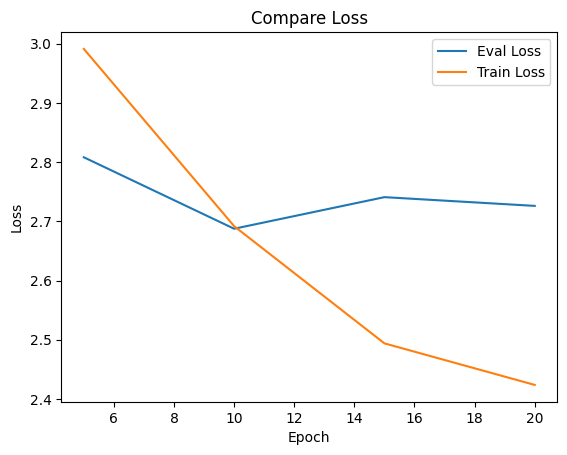

In [10]:
plt.plot(x, history["eval_loss"], label="Eval Loss")
plt.plot(x, history["loss"], label="Train Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Compare Loss")
plt.show()

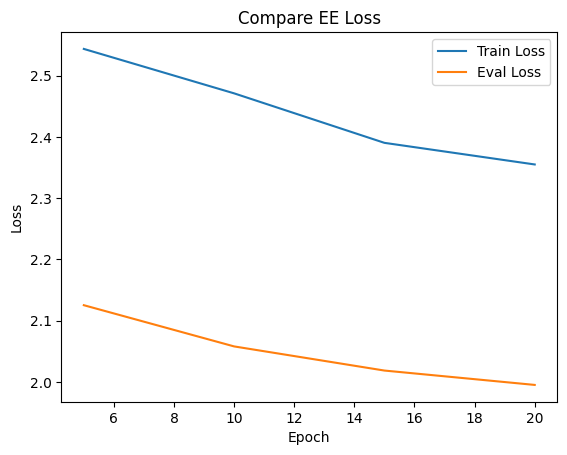

In [11]:
plt.plot(x, history["tie_loss"], label="Train Loss")
plt.plot(x, history["eval_tie_loss"], label="Eval Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Compare EE Loss")
plt.show()

In [16]:
GeoTKG = GeoTKG(use_ca=True).to(device="cuda")
load = torch.load("results\\geotkg\\geotkg_model_epoch20.pt")
GeoTKG.load_state_dict(load['model_state_dict'])

GeoTKG.evaluate_dataloaders(tie_test_loader, geo_eval_loader, norm_test_loader)

d:\GeoTKG\venv\Lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at roberta-base were not used when initializing RobertaModel: ['lm_head.dense.bias', 'lm_head.bias', 'lm_head.layer_norm.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.weight']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of RobertaModel were not initializ

              precision    recall  f1-score   support

        DATE     0.9218    0.9326    0.9272      2403
    DURATION     0.7611    0.7914    0.7760       302
       EVENT     0.9906    0.9899    0.9903     16900
         SET     0.6875    0.6875    0.6875        16
        TIME     0.5000    0.6596    0.5688        47

   micro avg     0.9767    0.9788    0.9778     19668
   macro avg     0.7722    0.8122    0.7899     19668
weighted avg     0.9772    0.9788    0.9780     19668

              precision    recall  f1-score   support

         0.0     0.9866    0.8683    0.9237     88218
         1.0     0.1370    0.6400    0.2257      2883

    accuracy                         0.8611     91101
   macro avg     0.5618    0.7541    0.5747     91101
weighted avg     0.9597    0.8611    0.9016     91101



d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GeoTKG\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

       AFTER     0.7460    0.9328    0.8290      6547
      BEFORE     0.3151    0.0451    0.0789       510
    CONTAINS     0.4000    0.0955    0.1542       335
      DURING     0.4151    0.0913    0.1497       482
      EQUALS     0.6291    0.4726    0.5397      2042
    IDENTITY     0.3623    0.2101    0.2660       119
    OVERLAPS     0.0000    0.0000    0.0000        13

    accuracy                         0.7162     10048
   macro avg     0.4097    0.2639    0.2882     10048
weighted avg     0.6675    0.7162    0.6693     10048

              precision    recall  f1-score   support

    LOCATION     0.5923    0.5964    0.5944      1006
     MINERAL     0.7911    0.9216    0.8514      1327
 ORE_DEPOSIT     0.8295    0.7624    0.7946       383
        ROCK     0.7708    0.8025    0.7863      1894
       STRAT     0.7977    0.7430    0.7694       642
   TIMESCALE     0.9431    0.9476    0.9454       210

   micro avg     0.7574

{'eval_loss': 2.380060987529383,
 'eval_tie_loss': 1.7420198187133333,
 'eval_geo_loss': 0.4461727554289155,
 'eval_norm_loss': 0.19186841338713423,
 'et_ner_f1': 0.9777552056881665,
 'geo_ner_f1': 0.7729962345346962,
 'et_f1': 0.8610662890637863,
 'ee_f1': 0.7161624203821656,
 'norm_strict': 0.7578174856413529,
 'norm_relaxed': 0.9218251435864709}